# Graph neural networks on Lund declustering graphs

This notebook is a tutorial on using a **graph neural network (GNN)** with the same Lund declustering graph convention used in `JetClusteringTree_Tutorial.ipynb`.

We will:

1. Rebuild the same mock jet-clustering tree used in the tree tutorial
2. Convert it into the same graph structure: one node per declustering, edges following the harder/softer tree
3. Use each node's Lund-coordinate vector as a GNN feature
4. Implement a minimal message-passing GNN in PyTorch
5. Connect the toy implementation back to the real `LundNet` code in this repository

The graph drawing helper is intentionally the same style as in `JetClusteringTree_Tutorial.ipynb`: nodes are arranged by depth and labels show the distance from the root.


In [13]:
# Repository imports and dependency checks.
import sys
from pathlib import Path
import importlib.util

debug = False

repo_root = Path.cwd()
if not (repo_root / "src" / "lundnet").exists():
    repo_root = repo_root.parent

src_dir = repo_root / "src"
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

required = ["numpy", "networkx", "matplotlib", "torch"]
missing = [name for name in required if importlib.util.find_spec(name) is None]
if missing:
    print("Missing optional tutorial dependencies:", missing)
    print("Install the LundNet environment before running all cells in this notebook.")
else:
    print("All tutorial dependencies are available.")


All tutorial dependencies are available.


## 1) The graph we will feed to a GNN

The graph convention is the same as in the jet-clustering tree tutorial:

- every accepted declustering becomes one graph node
- node features are Lund coordinates: `[lnz, lnDelta, psi, lnm, lnKt]`
- edges connect parent/child declusterings in the binary tree
- leaf particles are not graph nodes because they do not have Lund coordinates

The code below repeats the same mock FastJet-like objects so the tutorial can be run without requiring FastJet.


In [14]:
import math
import random
from dataclasses import dataclass
from typing import Optional

import numpy as np

class MockPseudoJet:
    def __init__(self, px, py, pz, E, parent1=None, parent2=None):
        self._px, self._py, self._pz, self._E = float(px), float(py), float(pz), float(E)
        self._p1 = parent1
        self._p2 = parent2

    def px(self): return self._px
    def py(self): return self._py
    def pz(self): return self._pz
    def E(self):  return self._E

    def pt(self):
        return math.hypot(self._px, self._py)

    def phi(self):
        return math.atan2(self._py, self._px)

    def rap(self):
        denom = max(self._E - self._pz, 1e-12)
        numer = max(self._E + self._pz, 1e-12)
        return 0.5 * math.log(numer / denom)

    def delta_R(self, other):
        dy = self.rap() - other.rap()
        dphi = self.phi() - other.phi()
        dphi = (dphi + math.pi) % (2*math.pi) - math.pi
        return math.sqrt(dy*dy + dphi*dphi)

    def has_parents(self, *_):
        return (self._p1 is not None) and (self._p2 is not None)

    def parents(self):
        return self._p1, self._p2

    def __add__(self, other):
        return MockPseudoJet(
            self._px + other._px,
            self._py + other._py,
            self._pz + other._pz,
            self._E  + other._E,
        )

    def m2(self):
        p2 = self._px**2 + self._py**2 + self._pz**2
        return self._E**2 - p2


def lund_coordinates_for_mock(j1: MockPseudoJet, j2: MockPseudoJet):
    delta = np.float32(max(1e-6, j1.delta_R(j2)))
    z = np.float32(j2.pt() / (j1.pt() + j2.pt()))
    lnm = np.float32(0.5 * math.log(max(abs((j1 + j2).m2()), 1e-12)))
    lnKt = np.float32(math.log(max(j2.pt() * delta, 1e-12)))
    lnz = np.float32(math.log(max(z, 1e-12)))
    lnDelta = np.float32(math.log(delta))
    try:
        psi = np.float32(math.atan((j1.rap() - j2.rap()) / (j1.phi() - j2.phi())))
    except ZeroDivisionError:
        psi = np.float32(0.0)
    return np.array([lnz, lnDelta, psi, lnm, lnKt], dtype="float32")


## 2) Build the same teaching Lund tree

This is the same recursive logic used in `JetClusteringTree_Tutorial.ipynb`: order branches by transverse momentum, apply optional cuts, and keep the harder/softer child pointers.


In [15]:
@dataclass
class TeachingJetTree:
    jet: MockPseudoJet
    child: Optional["TeachingJetTree"] = None
    harder: Optional["TeachingJetTree"] = None
    softer: Optional["TeachingJetTree"] = None
    delta2: float = 0.0
    lund: Optional[np.ndarray] = None


def build_teaching_tree(pj: MockPseudoJet, ktmin=0.0, deltamin=0.0, child=None):
    node = TeachingJetTree(jet=pj, child=child)

    current = pj
    while True:
        if not current.has_parents():
            break

        j1, j2 = current.parents()
        if j2.pt() > j1.pt():
            j1, j2 = j2, j1

        delta = j1.delta_R(j2)
        kt = j2.pt() * delta

        if delta < deltamin:
            break

        if kt >= ktmin:
            node.delta2 = float(delta * delta)
            node.lund = lund_coordinates_for_mock(j1, j2)
            node.harder = build_teaching_tree(j1, ktmin=ktmin, deltamin=deltamin, child=node)
            node.softer = build_teaching_tree(j2, ktmin=ktmin, deltamin=deltamin, child=node)
            break
        else:
            current = j1

    return node


def random_leaf(seed, pt_scale=50.0, energy_offset=(5.0, 50.0)):
    rng = random.Random(seed)
    px = rng.uniform(-pt_scale, pt_scale)
    py = rng.uniform(-pt_scale, pt_scale)
    pz = rng.uniform(-pt_scale, pt_scale)
    p = math.sqrt(px*px + py*py + pz*pz)
    E = p + rng.uniform(*energy_offset)
    return MockPseudoJet(px, py, pz, E)


def combine(a, b):
    return MockPseudoJet(a.px()+b.px(), a.py()+b.py(), a.pz()+b.pz(), a.E()+b.E(), parent1=a, parent2=b)


def make_mock_tree(seed=0, ktmin=0.0, deltamin=0.0, pt_scale=50.0):
    leaves = [random_leaf(seed * 100 + i, pt_scale=pt_scale) for i in range(8)]
    n01 = combine(leaves[0], leaves[1])
    n23 = combine(leaves[2], leaves[3])
    n45 = combine(leaves[4], leaves[5])
    n67 = combine(leaves[6], leaves[7])
    n0123 = combine(n01, n23)
    n4567 = combine(n45, n67)
    root = combine(n0123, n4567)
    return build_teaching_tree(root, ktmin=ktmin, deltamin=deltamin)

tree = make_mock_tree(seed=0)
tree_cut = make_mock_tree(seed=0, ktmin=20.0)
print("Built teaching trees.")


Built teaching trees.


## 3) Convert the tree to the same graph as the tree tutorial

This `teaching_tree_to_nx` helper matches the graph-building convention demonstrated in the previous notebook and mirrors `DGLGraphDatasetLund._build_tree`.


In [16]:
import networkx as nx


def teaching_tree_to_nx(root: TeachingJetTree, include_secondary=True):
    g = nx.Graph()

    root_features = root.lund if root.lund is not None else np.zeros(5, dtype="float32")
    if debug:
      print("Root features:", root_features)
    g.add_node(0, features=root_features)

    def rec(nid, node):
        branches = [node.harder, node.softer] if include_secondary else [node.harder]
        for br in branches:
            if br is None or br.lund is None:
                continue
            cid = g.number_of_nodes()
            if debug:
                print("Adding node:", cid, "with features:", br.lund)
            g.add_node(cid, features=br.lund)
            g.add_edge(cid, nid)
            rec(cid, br)

    rec(0, root)
    return g


g_nx = teaching_tree_to_nx(tree, include_secondary=True)
g_nx_cut = teaching_tree_to_nx(tree_cut, include_secondary=True)

print("Graph nodes (no cuts):", g_nx.number_of_nodes(), "edges:", g_nx.number_of_edges())
print("Graph nodes (ktmin=20):", g_nx_cut.number_of_nodes(), "edges:", g_nx_cut.number_of_edges())


Graph nodes (no cuts): 7 edges: 6
Graph nodes (ktmin=20): 7 edges: 6


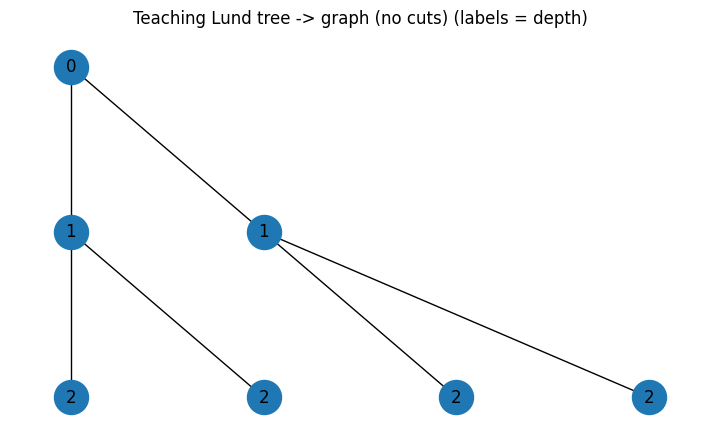

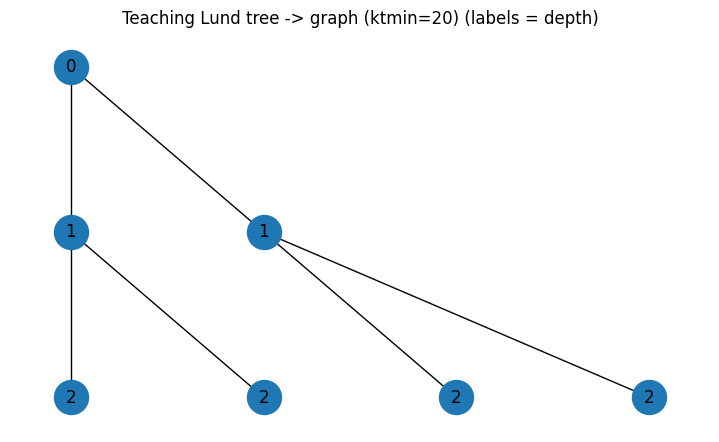

In [5]:
import matplotlib.pyplot as plt


def node_depths(g: nx.Graph, root=0):
    depths = {root: 0}
    queue = [root]
    while queue:
        u = queue.pop(0)
        for v in g.neighbors(u):
            if v not in depths:
                depths[v] = depths[u] + 1
                queue.append(v)
    return depths


def draw_graph(g, title=""):
    depths = node_depths(g, 0)
    layers = {}
    for n, d in depths.items():
        layers.setdefault(d, []).append(n)
    pos = {}
    for d, nodes in layers.items():
        for i, n in enumerate(sorted(nodes)):
            pos[n] = (i, -d)
    labels = {n: str(depths[n]) for n in g.nodes()}
    plt.figure(figsize=(7,4))
    nx.draw(g, pos, with_labels=True, labels=labels, node_size=600)
    plt.title(title + " (labels = depth)")
    plt.axis("off")
    plt.show()


draw_graph(g_nx, "Teaching Lund tree -> graph (no cuts)")
draw_graph(g_nx_cut, "Teaching Lund tree -> graph (ktmin=20)")


## 4) What a GNN receives

A GNN needs two objects:

- `X`: a node-feature matrix with shape `(number_of_nodes, number_of_features)`
- `A`: an adjacency matrix describing which nodes exchange messages

For this tutorial, `X` is the stack of Lund-coordinate vectors stored on graph nodes. `A` comes from the graph edges and includes self-loops so every node keeps its own information during message passing.


In [ ]:
def graph_to_numpy(g: nx.Graph):
    node_ids = sorted(g.nodes())
    x = np.stack([g.nodes[n]["features"] for n in node_ids]).astype("float32")
    a = nx.to_numpy_array(g, nodelist=node_ids, dtype="float32")
    a = a + np.eye(a.shape[0], dtype="float32")
    degree = np.maximum(a.sum(axis=1, keepdims=True), 1.0)
    a_mean = a / degree
    return x, a_mean

x_np, a_np = graph_to_numpy(g_nx)
print("X shape:", x_np.shape)
print("A shape:", a_np.shape)
print("First node feature vector [lnz, lnDelta, psi, lnm, lnKt]:")
print(x_np[0])


Node IDs in graph: [0, 1, 2, 3, 4, 5, 6]
Node features (X):
Node 0: [-1.9522291   1.1400853  -0.08514107  6.278376    4.0513554 ]
Node 1: [-0.7632694  -0.3806299   0.92634666  5.546949    3.5876205 ]
Node 2: [-0.77570933  0.5942605   0.28445563  4.769636    4.3561816 ]
Node 3: [-1.2252934   0.8002128   0.15865009  4.8379226   4.0801535 ]
Node 4: [-1.0088843e+00  7.3279953e-01 -2.9257077e-03  5.5453682e+00
  3.2201011e+00]
Node 5: [-1.0142086  1.121661   0.1594286  4.980256   4.4220433]
Node 6: [-0.7484478   1.0610702  -0.11626686  4.691636    4.7273893 ]
Adjacency matrix (A):
[[0. 1. 0. 0. 1. 0. 0.]
 [1. 0. 1. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 1. 1.]
 [0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0.]]
Adjacency matrix with self-loops (A + I):
[[1. 1. 0. 0. 1. 0. 0.]
 [1. 1. 1. 1. 0. 0. 0.]
 [0. 1. 1. 0. 0. 0. 0.]
 [0. 1. 0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 1. 1. 1.]
 [0. 0. 0. 0. 1. 1. 0.]
 [0. 0. 0. 0. 1. 0. 1.]]
X shape: (7, 5)
A shape: (7, 7)
First

## 5) A minimal message-passing layer

The simplest useful GNN update is:

```text
new_node_state = MLP(mean(neighbor_node_states))
```

That is the same idea as `LundNet.forward`: update node features through graph-aware layers, then pool all node states into one graph-level vector for classification.


In [7]:
import torch
from torch import nn
import torch.nn.functional as F


def to_torch_graph(g: nx.Graph):
    x, a = graph_to_numpy(g)
    return torch.tensor(x, dtype=torch.float32), torch.tensor(a, dtype=torch.float32)


class SimpleGraphConv(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)

    def forward(self, x, adjacency):
        messages = adjacency @ x
        return F.relu(self.linear(messages))


class SimpleGraphClassifier(nn.Module):
    def __init__(self, input_dims=5, hidden_dims=32, num_classes=2):
        super().__init__()
        self.conv1 = SimpleGraphConv(input_dims, hidden_dims)
        self.conv2 = SimpleGraphConv(hidden_dims, hidden_dims)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dims, hidden_dims),
            nn.ReLU(),
            nn.Linear(hidden_dims, num_classes),
        )

    def forward(self, x, adjacency):
        h = self.conv1(x, adjacency)
        h = self.conv2(h, adjacency)
        graph_embedding = h.mean(dim=0)
        return self.classifier(graph_embedding)


model = SimpleGraphClassifier(input_dims=x_np.shape[1])
x_t, a_t = to_torch_graph(g_nx)
logits = model(x_t, a_t)
print("logits shape:", tuple(logits.shape))
print("class probabilities:", torch.softmax(logits, dim=0).detach().numpy())


logits shape: (2,)
class probabilities: [0.5039414  0.49605855]


## 6) Train on a tiny synthetic dataset

The real LundNet training script reads QCD and signal samples from files. For a tutorial, we will create synthetic examples from the same mock tree builder.

The label below is deliberately simple: high-`pt_scale` trees are class `1`, lower-`pt_scale` trees are class `0`. This makes the training loop easy to inspect; it is not a physics analysis.


In [8]:
def make_tutorial_dataset(n_per_class=40):
    examples = []
    for i in range(n_per_class):
        g0 = teaching_tree_to_nx(make_mock_tree(seed=1000 + i, pt_scale=35.0))
        g1 = teaching_tree_to_nx(make_mock_tree(seed=2000 + i, pt_scale=70.0))
        examples.append((g0, 0))
        examples.append((g1, 1))
    random.Random(123).shuffle(examples)
    return examples


dataset = make_tutorial_dataset(n_per_class=50)
train_set = dataset[:80]
test_set = dataset[80:]
print("train graphs:", len(train_set), "test graphs:", len(test_set))


train graphs: 80 test graphs: 20


In [9]:
model = SimpleGraphClassifier(input_dims=5, hidden_dims=32, num_classes=2)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(20):
    model.train()
    total_loss = 0.0
    correct = 0
    for graph, label in train_set:
        x, a = to_torch_graph(graph)
        y = torch.tensor([label], dtype=torch.long)

        optimizer.zero_grad()
        logits = model(x, a).unsqueeze(0)
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += float(loss.detach())
        correct += int(logits.argmax(dim=1).item() == label)

    if epoch in {0, 1, 4, 9, 19}:
        print(f"epoch {epoch:02d}  loss={total_loss/len(train_set):.4f}  train_acc={correct/len(train_set):.3f}")


epoch 00  loss=0.6985  train_acc=0.525
epoch 01  loss=0.6920  train_acc=0.487
epoch 04  loss=0.6653  train_acc=0.588
epoch 09  loss=0.5752  train_acc=0.738
epoch 19  loss=0.4626  train_acc=0.812


In [10]:
model.eval()
correct = 0
with torch.no_grad():
    for graph, label in test_set:
        x, a = to_torch_graph(graph)
        pred = model(x, a).argmax().item()
        correct += int(pred == label)
print("test accuracy:", correct / len(test_set))


test accuracy: 0.85


## 7) How this maps to real LundNet

The toy model above uses the same conceptual steps as the real implementation:

1. `DGLGraphDatasetLund._build_tree(root)` creates graph nodes from Lund declusterings and stores node attributes named `features` and `coordinates`.
2. `collate_wrapper_tree` batches graphs and extracts the node-feature tensor.
3. `LundNet.forward(batch_graph, features)` applies EdgeConv blocks to update node states.
4. `dgl.mean_nodes(batch_graph, 'fts')` pools node states into one jet-level embedding.
5. The final fully connected layers classify the jet.

The main difference is that the production code uses DGL graphs and EdgeConv blocks, while this notebook used an explicit adjacency matrix so the message passing is visible in one line: `messages = adjacency @ x`.


In [11]:
# Optional: inspect the production model if DGL is installed in your environment.
try:
    from lundnet.LundNet import LundNet
    print(LundNet)
except Exception as exc:
    print("Could not import LundNet in this kernel:")
    print(type(exc).__name__ + ":", exc)


<class 'lundnet.LundNet.LundNet'>


## 8) Try the same data with the production script

After installing the full LundNet environment, the repository can train the real model on the included samples from the command line:

```bash
lundnet --demo --save test --device cpu --num-epochs 1
```

That command uses the DGL graph dataset and `LundNet` architecture instead of the tiny adjacency-matrix model above.
